In [ ]:
!pip install torch torchvision matplotlib pandas numpy

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_data = torchvision.datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Training Samples:", len(train_data))
print("Test Samples:", len(test_data))

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 218kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 4.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 18.5MB/s]

Training Samples: 60000
Test Samples: 10000


In [ ]:
train_loader = torch.utils.data.DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

print("DataLoader Created Successfully")

DataLoader Created Successfully


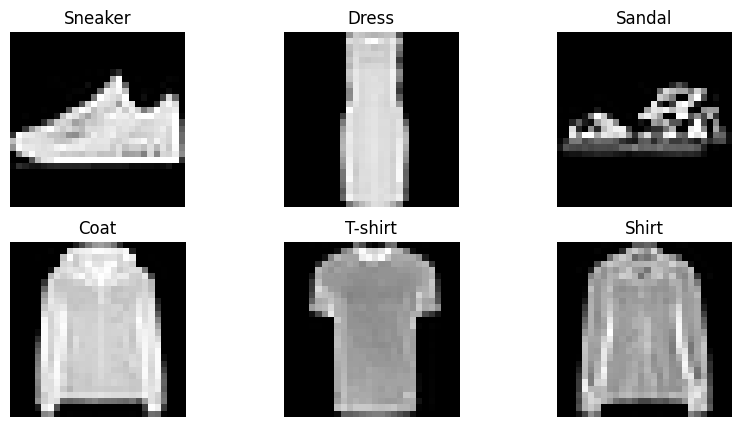

In [ ]:
classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(classes[labels[i]])
    plt.axis('off')

plt.show()

In [ ]:
class FashionModel(nn.Module):

    def __init__(self):
        super(FashionModel, self).__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(28*28, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FashionModel().to(device)

print(model)
print("Using Device:", device)

FashionModel(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)
Using Device: cpu


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and Optimizer Ready")

Loss and Optimizer Ready


In [ ]:
epochs = 5

train_losses = []
train_accuracies = []

for epoch in range(epochs):

    running_loss = 0
    correct = 0
    total = 0

    model.train()

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    train_losses.append(running_loss)

    train_accuracies.append(accuracy)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {running_loss:.4f} "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch [1/5] Loss: 493.8782 Accuracy: 81.05%
Epoch [2/5] Loss: 345.9326 Accuracy: 86.53%
Epoch [3/5] Loss: 313.3487 Accuracy: 87.72%
Epoch [4/5] Loss: 289.8758 Accuracy: 88.57%
Epoch [5/5] Loss: 274.2971 Accuracy: 89.18%


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 87.72


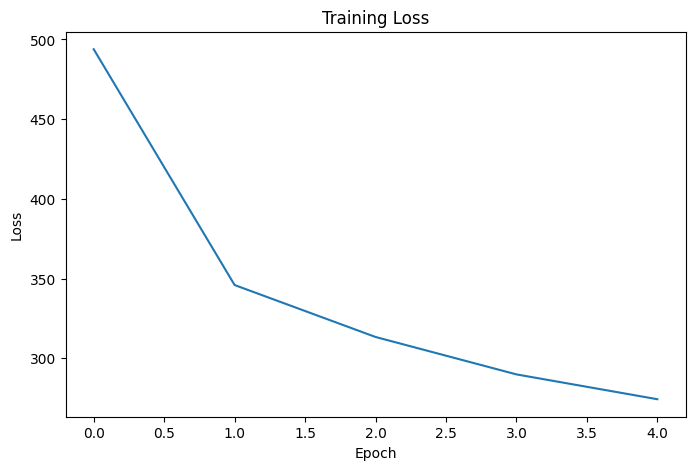

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

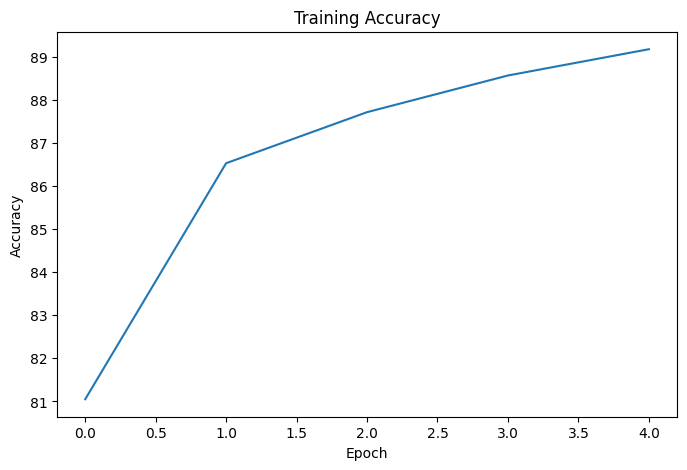

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
torch.save(
    model.state_dict(),
    "fashion_model.pth"
)

print("Model Saved")

Model Saved


In [ ]:
model.eval()

predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        predictions.extend(
            predicted.cpu().numpy()
        )

In [ ]:
submission = pd.DataFrame({
    "Id": range(len(predictions)),
    "Label": predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print(submission.head())
print("submission.csv saved")

   Id  Label
0   0      9
1   1      2
2   2      1
3   3      1
4   4      6
submission.csv saved
